In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('dataset/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3554, 19)

In [5]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,3,4,3+,2.0,Moderately Old,2200.0,0,1,0,0,0,1,123
1,1,flat,emaar digihomes,sector 62,2.15,14257.0,2,2,3,31.0,Under Construction,1676.0,0,0,0,0,0,0,101
2,2,flat,m3m heights,sector 65,2.44,13297.0,3,3,2,7.0,Under Construction,1654.0,0,0,0,0,0,0,31
3,3,flat,the close south,sector 50,3.10,12445.0,3,4,3+,4.0,Moderately Old,2450.0,0,1,0,0,0,1,165
4,4,flat,unitech the residences,sector 33,1.55,9873.0,3,4,1,1.0,Relatively New,1421.0,0,1,0,0,0,0,37


In [6]:
train_df=df.drop(columns=['society','price_per_sqft'])

In [7]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,sector 66,3.98,3,4,3+,2.0,Moderately Old,2200.0,0,1,0,0,0,1,123
1,1,flat,sector 62,2.15,2,2,3,31.0,Under Construction,1676.0,0,0,0,0,0,0,101
2,2,flat,sector 65,2.44,3,3,2,7.0,Under Construction,1654.0,0,0,0,0,0,0,31
3,3,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,2450.0,0,1,0,0,0,1,165
4,4,flat,sector 33,1.55,3,4,1,1.0,Relatively New,1421.0,0,1,0,0,0,0,37


<Axes: >

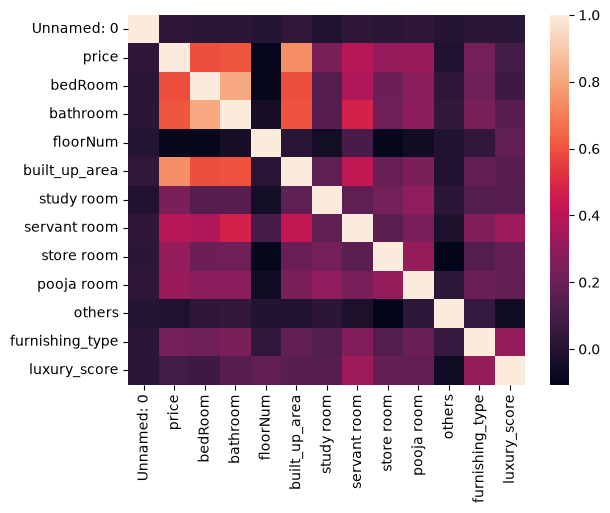

In [8]:
sns.heatmap(train_df.corr(numeric_only=True))

In [9]:
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price              1.000000
built_up_area      0.744312
bathroom           0.609777
bedRoom            0.591289
servant room       0.391930
pooja room         0.319852
store room         0.305677
study room         0.242955
furnishing_type    0.223426
luxury_score       0.091473
Unnamed: 0         0.029689
others            -0.013064
floorNum          -0.087442
Name: price, dtype: float64

<Axes: xlabel='luxury_score'>

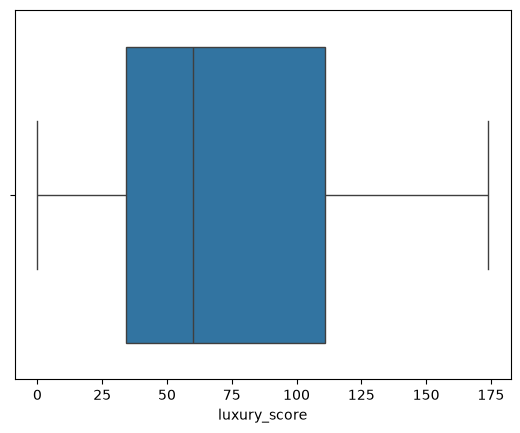

In [11]:
sns.boxplot(x=train_df['luxury_score'])

In [8]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [9]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [10]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,0,flat,sector 66,3.98,3,4,3+,2.0,Moderately Old,2200.0,0,1,0,0,0,1,123,Medium
1,1,flat,sector 62,2.15,2,2,3,31.0,Under Construction,1676.0,0,0,0,0,0,0,101,Medium
2,2,flat,sector 65,2.44,3,3,2,7.0,Under Construction,1654.0,0,0,0,0,0,0,31,Low
3,3,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,2450.0,0,1,0,0,0,1,165,High
4,4,flat,sector 33,1.55,3,4,1,1.0,Relatively New,1421.0,0,1,0,0,0,0,37,Low


<Axes: xlabel='floorNum'>

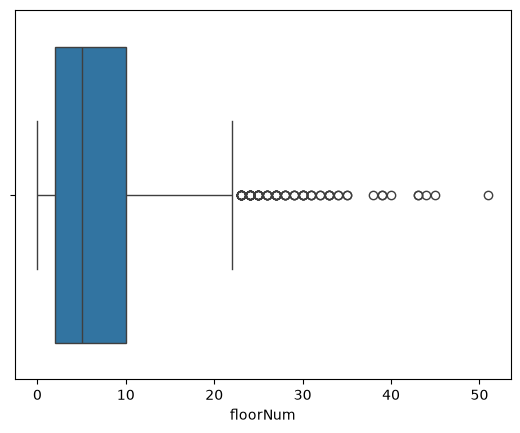

In [16]:
sns.boxplot(x=df['floorNum'])

In [11]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [12]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [13]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,0,flat,sector 66,3.98,3,4,3+,2.0,Moderately Old,2200.0,0,1,0,0,0,1,123,Medium,Low Floor
1,1,flat,sector 62,2.15,2,2,3,31.0,Under Construction,1676.0,0,0,0,0,0,0,101,Medium,High Floor
2,2,flat,sector 65,2.44,3,3,2,7.0,Under Construction,1654.0,0,0,0,0,0,0,31,Low,Mid Floor
3,3,flat,sector 50,3.10,3,4,3+,4.0,Moderately Old,2450.0,0,1,0,0,0,1,165,High,Mid Floor
4,4,flat,sector 33,1.55,3,4,1,1.0,Relatively New,1421.0,0,1,0,0,0,0,37,Low,Low Floor


In [14]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [15]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,flat,sector 66,3.98,3,4,3+,Moderately Old,2200.0,0,1,0,0,0,1,Medium,Low Floor
1,1,flat,sector 62,2.15,2,2,3,Under Construction,1676.0,0,0,0,0,0,0,Medium,High Floor
2,2,flat,sector 65,2.44,3,3,2,Under Construction,1654.0,0,0,0,0,0,0,Low,Mid Floor
3,3,flat,sector 50,3.10,3,4,3+,Moderately Old,2450.0,0,1,0,0,0,1,High,Mid Floor
4,4,flat,sector 33,1.55,3,4,1,Relatively New,1421.0,0,1,0,0,0,0,Low,Low Floor


In [16]:
train_df.columns

Index(['Unnamed: 0', 'property_type', 'sector', 'price', 'bedRoom', 'bathroom',
       'balcony', 'agePossession', 'built_up_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury_category', 'floor_category'],
      dtype='str')

In [17]:
train_df.drop(columns=['Unnamed: 0','study room','pooja room','others'],inplace=True)

In [18]:
train_df.columns

Index(['property_type', 'sector', 'price', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category'],
      dtype='str')

In [19]:
train_df.to_csv('dataset/gurgaon_properties_post_feature_selection_v2.csv', index=False)

In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 55',
       'sector 56', 'sector 57', 'sector 58', 'sector

C:\Users\HEMANT\AppData\Local\Temp\ipykernel_8048\848989002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


In [25]:
X_label

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,0.0,72.0,3,4,4.0,0.0,2200.0,0,1,0,0,0,1,2.0,1.0
1,1,0.0,68.0,2,2,3.0,4.0,1676.0,0,0,0,0,0,0,2.0,0.0
2,2,0.0,71.0,3,3,2.0,4.0,1654.0,0,0,0,0,0,0,1.0,2.0
3,3,0.0,55.0,3,4,4.0,0.0,2450.0,0,1,0,0,0,1,0.0,2.0
4,4,0.0,37.0,3,4,1.0,3.0,1421.0,0,1,0,0,0,0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,3550,0.0,5.0,3,4,4.0,3.0,3716.0,1,1,0,1,1,1,1.0,2.0
3550,3551,0.0,38.0,3,2,3.0,4.0,978.0,0,0,0,0,0,0,1.0,2.0
3551,3552,1.0,77.0,2,2,1.0,3.0,200.0,0,0,0,0,0,0,1.0,1.0
3552,3553,0.0,101.0,2,2,3.0,3.0,1444.0,0,0,0,0,0,0,2.0,2.0


In [26]:
y_label

0       3.98
1       2.15
2       2.44
3       3.10
4       1.55
        ... 
3549    1.90
3550    0.72
3551    2.00
3552    0.75
3553    0.92
Name: price, Length: 3554, dtype: float64

Technique 1- Correlation Analysis

<Axes: >

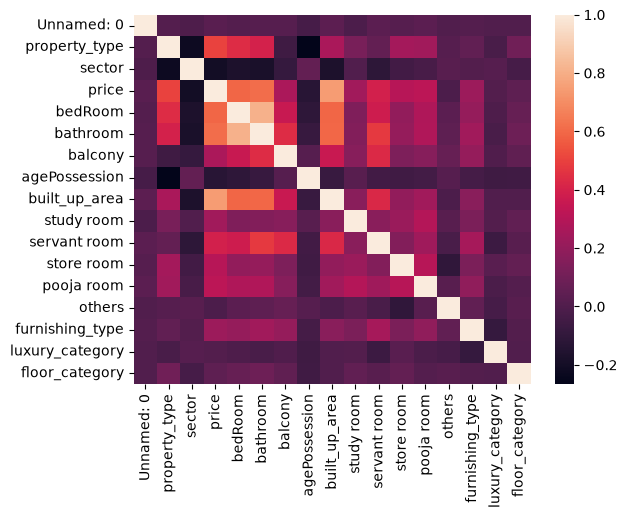

In [27]:
sns.heatmap(data_label_encoded.corr(numeric_only=True))

In [28]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,property_type,0.503728
1,sector,-0.202943
2,price,1.000000
3,bedRoom,0.591289
4,bathroom,0.609777
5,balcony,0.269637
6,agePossession,-0.132673
7,built_up_area,0.744312
8,study room,0.242955
9,servant room,0.391930


Techinique 2-Random Forest Feature Importance

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.639336
1,property_type,0.104640
2,sector,0.095467
0,Unnamed: 0,0.032427
4,bathroom,0.025412
3,bedRoom,0.021207
9,servant room,0.018253
6,agePossession,0.010645
5,balcony,0.010605
13,furnishing_type,0.009180


Technique 3- Gradient Boosting Feature Importances

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.674093
1,property_type,0.103541
2,sector,0.099749
3,bedRoom,0.033281
4,bathroom,0.031903
9,servant room,0.025494
0,Unnamed: 0,0.011322
10,store room,0.009441
13,furnishing_type,0.003419
6,agePossession,0.002964


Technique 4- Permutation Importance

In [31]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
7,built_up_area,0.689523
1,property_type,0.195029
2,sector,0.127365
9,servant room,0.021840
0,Unnamed: 0,0.007108
8,study room,0.005814
3,bedRoom,0.004590
5,balcony,0.003998
4,bathroom,0.003833
6,agePossession,0.003074


Technique 5- LASSO

In [32]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
7,built_up_area,1.512832
1,property_type,0.760447
4,bathroom,0.270410
10,store room,0.190306
8,study room,0.168507
9,servant room,0.159342
13,furnishing_type,0.154575
11,pooja room,0.078954
14,luxury_category,0.052192
3,bedRoom,0.018043


Technique 6- RFE

In [33]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
7,built_up_area,0.639382
1,property_type,0.107574
2,sector,0.094301
0,Unnamed: 0,0.035875
4,bathroom,0.021036
3,bedRoom,0.020672
9,servant room,0.020048
6,agePossession,0.011218
5,balcony,0.010232
13,furnishing_type,0.008444


Technique 7- Linear Regression Weights

In [35]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
7,built_up_area,1.515601
1,property_type,0.761193
4,bathroom,0.276749
10,store room,0.194741
8,study room,0.176356
9,servant room,0.168706
13,furnishing_type,0.163856
11,pooja room,0.081991
14,luxury_category,0.063749
3,bedRoom,0.020781


Technique 8- SHAP

In [36]:
!pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 2.2 MB/s eta 0:00:20
   - -------------------------------------- 1.3/43.0 MB 2.9 MB/s eta 0:00:15
   - -------------------------------------- 2.1/43.0 MB 3.2 MB/s eta 0:00:13
   -- ------------------------------------- 2.9/43.0 MB 3.4 MB/s eta 0:00:12
   --- ------------------------------------ 3.7/43.0 MB 3.5 MB/s eta 0:00:12
   --- ------------------------------------ 4.2/43.0 MB 3.3 MB/s eta 0:00:12
   ---- ----------------------------------- 5.0/43.0 MB 3.4 MB/s eta 0:00:12
   ----- ---------------------------------- 5.8/43.0 MB 3.4 MB/s eta 0:00:12
   ----- ---------------------------------- 6.3/43.0 MB 3.3 MB/s eta 0:00:12
   ------ --------------------------------- 6.8/43.0 MB 3.2 MB/s eta 0:00:12
   ------ --------------------------------- 6.8/43.0 MB 3.2 MB/s eta 0:00:12
   ------ --------------------------------- 6.8/43.0 MB 3.2 MB/s eta 0:00:12
   ---

In [37]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 0.13571333, -0.47882301,  0.81976038, ..., -0.00100341,
         0.01434329,  0.01469962],
       [ 0.04418642, -0.18902274,  0.8215916 , ..., -0.01592442,
        -0.00686034,  0.01091316],
       [ 0.03292122, -0.18359197,  0.76536236, ..., -0.01840729,
         0.00249571, -0.00668402],
       ...,
       [ 0.07854411,  0.43375958,  0.04001964, ..., -0.01343687,
        -0.00634938, -0.00435947],
       [ 0.01272686, -0.22441353, -0.49660086, ..., -0.01094477,
        -0.00201191, -0.00865479],
       [ 0.02053074,  0.52309499,  0.07722596, ..., -0.02620275,
        -0.00998428, -0.00259081]], shape=(3554, 16))

In [38]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,1.249884
1,property_type,0.479920
2,sector,0.366904
4,bathroom,0.137885
9,servant room,0.091790
3,bedRoom,0.047506
0,Unnamed: 0,0.036231
5,balcony,0.035927
13,furnishing_type,0.025481
6,agePossession,0.021493


In [39]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [40]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.503728,0.104640,0.103541,0.195029,0.760447,0.107574,0.761193,0.479920
sector,-0.202943,0.095467,0.099749,0.127365,-0.052101,0.094301,-0.061081,0.366904
bedRoom,0.591289,0.021207,0.033281,0.004590,0.018043,0.020672,0.020781,0.047506
bathroom,0.609777,0.025412,0.031903,0.003833,0.270410,0.021036,0.276749,0.137885
balcony,0.269637,0.010605,0.001200,0.003998,-0.035708,0.010232,-0.058445,0.035927
agePossession,-0.132673,0.010645,0.002964,0.003074,-0.000000,0.011218,0.003208,0.021493
built_up_area,0.744312,0.639336,0.674093,0.689523,1.512832,0.639382,1.515601,1.249884
study room,0.242955,0.006373,0.002647,0.005814,0.168507,0.005919,0.176356,0.018364
servant room,0.391930,0.018253,0.025494,0.021840,0.159342,0.020048,0.168706,0.091790


In [41]:
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [42]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.629219
property_type      0.139343
sector             0.112304
bathroom           0.027639
servant room       0.024420
bedRoom            0.020005
balcony            0.008136
agePossession      0.007396
furnishing_type    0.006498
store room         0.006299
study room         0.005619
floor_category     0.004074
pooja room         0.003903
luxury_category    0.003465
others             0.001678
dtype: float64

In [43]:
X_label

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0,0.0,72.0,3,4,4.0,0.0,2200.0,0,1,0,0,0,1,2.0,1.0
1,1,0.0,68.0,2,2,3.0,4.0,1676.0,0,0,0,0,0,0,2.0,0.0
2,2,0.0,71.0,3,3,2.0,4.0,1654.0,0,0,0,0,0,0,1.0,2.0
3,3,0.0,55.0,3,4,4.0,0.0,2450.0,0,1,0,0,0,1,0.0,2.0
4,4,0.0,37.0,3,4,1.0,3.0,1421.0,0,1,0,0,0,0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,3550,0.0,5.0,3,4,4.0,3.0,3716.0,1,1,0,1,1,1,1.0,2.0
3550,3551,0.0,38.0,3,2,3.0,4.0,978.0,0,0,0,0,0,0,1.0,2.0
3551,3552,1.0,77.0,2,2,1.0,3.0,200.0,0,0,0,0,0,0,1.0,1.0
3552,3553,0.0,101.0,2,2,3.0,3.0,1444.0,0,0,0,0,0,0,2.0,2.0


In [44]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [45]:
scores.mean()

np.float64(0.7800267623813198)

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [47]:
scores.mean()

np.float64(0.7811612913251287)

In [48]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [49]:
export_df.to_csv('dataset/gurgaon_properties_post_feature_selection.csv', index=False)

In [50]:
export_df

,Unnamed: 0,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0,0.0,72.0,3,4,4.0,0.0,2200.0,1,0,1,2.0,1.0,3.98
1,1,0.0,68.0,2,2,3.0,4.0,1676.0,0,0,0,2.0,0.0,2.15
2,2,0.0,71.0,3,3,2.0,4.0,1654.0,0,0,0,1.0,2.0,2.44
3,3,0.0,55.0,3,4,4.0,0.0,2450.0,1,0,1,0.0,2.0,3.10
4,4,0.0,37.0,3,4,1.0,3.0,1421.0,1,0,0,1.0,1.0,1.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,3550,0.0,5.0,3,4,4.0,3.0,3716.0,1,0,1,1.0,2.0,1.90
3550,3551,0.0,38.0,3,2,3.0,4.0,978.0,0,0,0,1.0,2.0,0.72
3551,3552,1.0,77.0,2,2,1.0,3.0,200.0,0,0,0,1.0,1.0,2.00
3552,3553,0.0,101.0,2,2,3.0,3.0,1444.0,0,0,0,2.0,2.0,0.75
